# Real Data

In [1]:
import pandas as pd

path = "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/rf_augmented/ui_data/unique_bending_setups.csv"

bending_setup_df = pd.read_csv(path)

In [2]:
import ast
import pandas as pd


excluded_experiments = {1, 48, 166}


def remove_excluded_experiments(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if not isinstance(value, (list, tuple, set)):
        value = [value]

    return [
        int(exp_id)
        for exp_id in value
        if int(exp_id) not in excluded_experiments
    ]


bending_setup_df = pd.read_csv(path)
bending_setup_df["Experiment_Number"] = bending_setup_df[
    "Experiment_Number"
].apply(remove_excluded_experiments)

bending_setup_df = bending_setup_df[
    bending_setup_df["Experiment_Number"].apply(len) > 0
].reset_index(drop=True)

#bending_setup_df.head(4)

In [3]:
bending_setup_df = bending_setup_df.copy()

bending_setup_df.insert(
    0,
    "Group_ID",
    range(1, len(bending_setup_df) + 1)
)

## Per-split train vs test value comparison

Use the widget below to pick a `split_index` and a column from `bending_setup_df`.
Numeric columns show box+points for train vs test. Categorical columns show grouped counts.

In [4]:
import pandas as pd
import numpy as np
from itertools import combinations, product


# =============================================================================
# Configuration
# =============================================================================
# Use the augmented bending-setup frame for split testing.
split_source_df = bending_setup_df.copy()
df = split_source_df.copy()

group_col = "Group_ID"
exp_col = "Experiment_Number"

random_state = 42
target_test_ratio = 0.20

# High-variation group split
variation_quantile = 0.70
variation_cols = None

# Floating-point comparison tolerance
float_tolerance = 1e-8

# Enable or disable split strategies
create_high_variation_split = True
create_single_feature_splits = True
create_two_feature_combination_splits = True
create_three_feature_combination_splits = True

# Features used for value-based splitting
important_split_features = {
    "Mandrel retraction timing": [
        0.0,
        2.0,
        5.0,
        10.0,
    ],
    "Collet boost": [
        0.85,
        0.87,
        0.90,
        0.92,
        0.95,
    ],
    "Pressure-die distance": [
        0.30,
        0.60,
        0.90,
    ],
}

# Columns excluded from the variation score
ignore_cols = [
    "Group_ID",
    "Experiment_Number",
    "Tube_numbers",
    "Mandrel position",
    "Experiment_ID",
    "Tube",
    "Outer-diameter",
    "Wall-thickness",
    "Wiper-die shortening",
    "Target-angle",
    "Pressure-die lateral position",
]


# =============================================================================
# Helper functions
# =============================================================================
def as_list(x):
    """Convert scalar or list-like experiment values to a Python list."""
    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        return list(x)

    if pd.isna(x):
        return []

    return [x]


def format_value(value):
    """Format numeric values for readable split names and metadata."""
    if isinstance(value, (float, np.floating)):
        return f"{float(value):g}"

    return str(value)


def format_values(values):
    """Format a collection of values as a readable string."""
    return ", ".join(format_value(value) for value in values)


def format_test_value_for_metadata(x):
    """Format list-like values before storing them in the summary table."""
    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        return format_values(list(x))

    return x


def count_experiments(input_df):
    """Count experiments when Experiment_Number may contain lists."""
    if input_df.empty:
        return 0

    return (
        input_df[exp_col]
        .apply(lambda x: len(as_list(x)))
        .sum()
    )


def safe_value_mask(series, values, tolerance=1e-8):
    """
    Create a boolean mask with safe floating-point comparison.

    Numeric values are compared with np.isclose.
    Non-numeric values are compared with Series.isin.
    """
    values = list(values)

    if pd.api.types.is_numeric_dtype(series):
        numeric_values = np.asarray(values, dtype=float)

        return series.apply(
            lambda x: (
                False
                if pd.isna(x)
                else np.any(
                    np.isclose(
                        float(x),
                        numeric_values,
                        atol=tolerance,
                        rtol=0,
                    )
                )
            )
        )

    return series.isin(values)


def get_split_stats(
    split_name,
    split_type,
    train_condition,
    test_condition,
    train_df,
    test_df,
):
    """Create metadata and summary statistics for one split."""
    train_exp = count_experiments(train_df)
    test_exp = count_experiments(test_df)
    total_exp = train_exp + test_exp

    train_groups = sorted(
        train_df[group_col].dropna().unique().tolist()
    )

    test_groups = sorted(
        test_df[group_col].dropna().unique().tolist()
    )

    overlap_groups = sorted(
        set(train_groups).intersection(test_groups)
    )

    return {
        "Split name": split_name,
        "Split type": split_type,
        "Train condition": train_condition,
        "Test condition": test_condition,
        "Train groups": len(train_groups),
        "Test groups": len(test_groups),
        "Train Group_IDs": train_groups,
        "Test Group_IDs": test_groups,
        "Train experiments": train_exp,
        "Test experiments": test_exp,
        "Test experiment (%)": (
            round(100 * test_exp / total_exp, 2)
            if total_exp > 0
            else np.nan
        ),
        "Group overlap": overlap_groups,
    }


def create_group_level_split(input_df, test_row_mask):
    """
    Create a leakage-free split at Group_ID level.

    If at least one row of a group satisfies the test condition,
    the complete group is assigned to the test set.
    """
    test_groups = (
        input_df.loc[test_row_mask, group_col]
        .dropna()
        .unique()
        .tolist()
    )

    test_df = input_df[
        input_df[group_col].isin(test_groups)
    ].copy()

    train_df = input_df[
        ~input_df[group_col].isin(test_groups)
    ].copy()

    return (
        train_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def add_group_split(
    split_storage,
    stats_storage,
    split_name,
    split_type,
    train_condition,
    test_condition,
    test_row_mask,
):
    """
    Create, validate, and store a group-level train/test split.
    """
    train_df, test_df = create_group_level_split(
        input_df=df,
        test_row_mask=test_row_mask,
    )

    # Ignore invalid splits with an empty train or test set
    if train_df.empty or test_df.empty:
        return

    train_groups = set(train_df[group_col].unique())
    test_groups = set(test_df[group_col].unique())

    overlap = train_groups.intersection(test_groups)

    if overlap:
        raise ValueError(
            f"Group leakage detected in split '{split_name}': {overlap}"
        )

    split_storage[split_name] = {
        "train": train_df,
        "test": test_df,
    }

    stats_storage.append(
        get_split_stats(
            split_name=split_name,
            split_type=split_type,
            train_condition=train_condition,
            test_condition=test_condition,
            train_df=train_df,
            test_df=test_df,
        )
    )


def select_test_groups_by_experiment_count(
    group_ids,
    input_df,
    target_experiment_count,
    random_state=42,
):
    """
    Select complete groups so that the test experiment count is
    approximately equal to the requested target.

    Groups are never split between train and test.
    """
    rng = np.random.default_rng(random_state)

    group_exp_counts = (
        input_df[input_df[group_col].isin(group_ids)]
        .groupby(group_col)[exp_col]
        .apply(
            lambda s: s.apply(
                lambda x: len(as_list(x))
            ).sum()
        )
        .to_dict()
    )

    shuffled_groups = list(group_ids)
    rng.shuffle(shuffled_groups)

    selected_groups = []
    selected_count = 0

    for group_id in shuffled_groups:
        group_count = group_exp_counts[group_id]

        current_difference = abs(
            target_experiment_count - selected_count
        )

        new_difference = abs(
            target_experiment_count
            - (selected_count + group_count)
        )

        if (
            selected_count < target_experiment_count
            or new_difference < current_difference
        ):
            selected_groups.append(group_id)
            selected_count += group_count

    return selected_groups


def get_available_configured_values(
    input_df,
    feature,
    configured_values,
):
    """
    Return only configured values that actually exist in the dataset.
    """
    available_values = []

    for value in configured_values:
        value_exists = safe_value_mask(
            input_df[feature],
            [value],
            tolerance=float_tolerance,
        ).any()

        if value_exists:
            available_values.append(value)

    return available_values


# =============================================================================
# Validate required columns
# =============================================================================
required_columns = {
    group_col,
    exp_col,
    *important_split_features.keys(),
}

missing_columns = sorted(
    required_columns.difference(df.columns)
)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )


# =============================================================================
# Output containers
# =============================================================================
new_splits = {}
new_stats = []

# =============================================================================
# Strategy 2: Single-feature value-subset splits
# =============================================================================
#
# For each important feature, all non-empty train/test partitions of its
# configured values are generated.
#
# Example for Mandrel retraction timing:
#
# Train values: [0, 2]
# Test values:  [5, 10]
#
# The reverse direction is also generated:
#
# Train values: [5, 10]
# Test values:  [0, 2]
#
# Three-to-one and one-to-three splits are also generated.
# =============================================================================
if create_single_feature_splits:

    for feature, configured_values in important_split_features.items():

        available_values = get_available_configured_values(
            input_df=df,
            feature=feature,
            configured_values=configured_values,
        )

        number_of_values = len(available_values)

        if number_of_values < 2:
            continue

        for train_size in range(1, number_of_values):

            for train_values_tuple in combinations(
                available_values,
                train_size,
            ):
                train_values = list(train_values_tuple)

                test_values = [
                    value
                    for value in available_values
                    if value not in train_values
                ]

                test_row_mask = safe_value_mask(
                    df[feature],
                    test_values,
                    tolerance=float_tolerance,
                )

                train_label = format_values(train_values)
                test_label = format_values(test_values)

                split_name = (
                    f"single"
                    f"__{feature}"
                    f"__train_[{train_label}]"
                    f"__test_[{test_label}]"
                )

                add_group_split(
                    split_storage=new_splits,
                    stats_storage=new_stats,
                    split_name=split_name,
                    split_type="Single-feature value split",
                    train_condition={
                        feature: train_values,
                    },
                    test_condition={
                        feature: test_values,
                    },
                    test_row_mask=test_row_mask,
                )


# =============================================================================
# Strategy 3: Two-feature combination holdout
# =============================================================================
#
# A specific combination of two feature values is held out.
#
# Example:
#
# Mandrel retraction timing = 0
# AND
# Collet boost = 0.85
#
# Groups containing this exact combination are assigned to test.
# Other combinations containing either value can remain in training.
#
# This evaluates generalization to unseen interactions between two features.
# =============================================================================
if create_two_feature_combination_splits:

    for feature_1, feature_2 in combinations(
        important_split_features.keys(),
        2,
    ):
        values_1 = get_available_configured_values(
            input_df=df,
            feature=feature_1,
            configured_values=important_split_features[feature_1],
        )

        values_2 = get_available_configured_values(
            input_df=df,
            feature=feature_2,
            configured_values=important_split_features[feature_2],
        )

        for value_1, value_2 in product(
            values_1,
            values_2,
        ):
            mask_1 = safe_value_mask(
                df[feature_1],
                [value_1],
                tolerance=float_tolerance,
            )

            mask_2 = safe_value_mask(
                df[feature_2],
                [value_2],
                tolerance=float_tolerance,
            )

            # Hold out only rows containing the exact two-feature combination
            test_row_mask = mask_1 & mask_2

            split_name = (
                f"pair"
                f"__{feature_1}={format_value(value_1)}"
                f"__AND"
                f"__{feature_2}={format_value(value_2)}"
            )

            add_group_split(
                split_storage=new_splits,
                stats_storage=new_stats,
                split_name=split_name,
                split_type="Two-feature combination holdout",
                train_condition=(
                    "All groups except groups containing "
                    "the held-out two-feature combination"
                ),
                test_condition={
                    feature_1: value_1,
                    feature_2: value_2,
                    "logic": "AND",
                },
                test_row_mask=test_row_mask,
            )


# =============================================================================
# Strategy 4: Three-feature combination holdout
# =============================================================================
#
# A specific combination of all three important features is held out.
#
# Example:
#
# Mandrel retraction timing = 0
# AND
# Collet boost = 0.85
# AND
# Pressure-die distance = 0.30
#
# Groups containing this exact operating condition are assigned to test.
# Other combinations of the same individual values can remain in training.
#
# This evaluates generalization to unseen three-feature interactions.
# =============================================================================
if create_three_feature_combination_splits:

    selected_features = list(
        important_split_features.keys()
    )

    if len(selected_features) >= 3:

        feature_1 = selected_features[0]
        feature_2 = selected_features[1]
        feature_3 = selected_features[2]

        values_1 = get_available_configured_values(
            input_df=df,
            feature=feature_1,
            configured_values=important_split_features[feature_1],
        )

        values_2 = get_available_configured_values(
            input_df=df,
            feature=feature_2,
            configured_values=important_split_features[feature_2],
        )

        values_3 = get_available_configured_values(
            input_df=df,
            feature=feature_3,
            configured_values=important_split_features[feature_3],
        )

        for value_1, value_2, value_3 in product(
            values_1,
            values_2,
            values_3,
        ):
            mask_1 = safe_value_mask(
                df[feature_1],
                [value_1],
                tolerance=float_tolerance,
            )

            mask_2 = safe_value_mask(
                df[feature_2],
                [value_2],
                tolerance=float_tolerance,
            )

            mask_3 = safe_value_mask(
                df[feature_3],
                [value_3],
                tolerance=float_tolerance,
            )

            # Hold out only rows containing the exact three-feature combination
            test_row_mask = mask_1 & mask_2 & mask_3

            split_name = (
                f"triple"
                f"__{feature_1}={format_value(value_1)}"
                f"__AND"
                f"__{feature_2}={format_value(value_2)}"
                f"__AND"
                f"__{feature_3}={format_value(value_3)}"
            )

            add_group_split(
                split_storage=new_splits,
                stats_storage=new_stats,
                split_name=split_name,
                split_type="Three-feature combination holdout",
                train_condition=(
                    "All groups except groups containing "
                    "the held-out three-feature combination"
                ),
                test_condition={
                    feature_1: value_1,
                    feature_2: value_2,
                    feature_3: value_3,
                    "logic": "AND",
                },
                test_row_mask=test_row_mask,
            )


# =============================================================================
# Summary
# =============================================================================
new_split_summary_df = pd.DataFrame(new_stats)

if not new_split_summary_df.empty:
    new_split_summary_df = (
        new_split_summary_df
        .sort_values(
            by=[
                "Split type",
                "Split name",
            ],
            key=lambda series: series.astype(str),
        )
        .reset_index(drop=True)
    )


print(f"Number of generated splits: {len(new_splits)}")

#display(new_split_summary_df)


Number of generated splits: 124


## QRF hyperparameter tuning on augmented split data

Run the `3_1_tune_qrf_hyperparameters.py` grid on the real geometry only for each value-based split, then aggregate the split results to choose one robust QRF configuration.


In [6]:
import ast
import importlib.util
import json
import re
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == "exploration":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

tuning_module_path = project_root / "3_1_tune_qrf_hyperparameters.py"
spec = importlib.util.spec_from_file_location(
    "qrf_hyperparameter_tuning",
    tuning_module_path,
)
qrf_tuning = importlib.util.module_from_spec(spec)
spec.loader.exec_module(qrf_tuning)

from src.pipeline.ml.qrf.data_splittor import DataSplittor
from src.pipeline.ml.qrf.geometry_data_preprocessor import GeometryPreprocessor
from src.pipeline.ml.qrf.qrf_pipeline import qrf_training_geometry_sources
from src.pipeline.rf_augmentation.io_utils import read_table

output_dir = project_root / "data" / "qrf" / "split"
tuning_output_dir = output_dir / "tuning"
tuning_model_dir = tuning_output_dir / "models_real"
tuning_output_dir.mkdir(parents=True, exist_ok=True)
tuning_model_dir.mkdir(parents=True, exist_ok=True)

real_split_summary_path = (
    tuning_output_dir / "real_split_hyperparameter_tuning_summary.csv"
)
real_config_summary_path = (
    tuning_output_dir / "real_split_hyperparameter_config_summary.csv"
)


def parse_experiment_numbers(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if isinstance(value, (list, tuple, set)):
        return [int(exp_id) for exp_id in value]

    return [int(value)]


def json_list(values):
    return json.dumps([int(value) for value in values])


def make_slug(value):
    slug = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")
    return slug or "split"


def experiments_for_groups(group_ids):
    group_ids = [int(group_id) for group_id in group_ids]
    group_rows = bending_for_qrf[bending_for_qrf["Group_ID"].isin(group_ids)]
    experiments = [
        exp_id
        for experiment_numbers in group_rows["Experiment_Number"]
        for exp_id in experiment_numbers
    ]
    return sorted(int(exp_id) for exp_id in experiments)


def extract_split_label(split_row):
    split_column = split_row.get("Split column")
    test_value = split_row.get("Test value")

    if pd.notna(split_column) and pd.notna(test_value):
        return split_column, test_value

    split_name = split_row.get("Split name")
    if isinstance(split_name, str) and split_name:
        return "split", split_name

    test_condition = split_row.get("Test condition")
    if isinstance(test_condition, dict):
        feature_names = [
            key for key in test_condition.keys() if key != "logic"
        ]
        if feature_names:
            feature = feature_names[0]
            return feature, test_condition[feature]

    return "split", "unknown"


bending_for_qrf = bending_setup_df.copy()
if "Group_ID" not in bending_for_qrf.columns:
    bending_for_qrf.insert(0, "Group_ID", range(1, len(bending_for_qrf) + 1))

bending_for_qrf["Experiment_Number"] = bending_for_qrf[
    "Experiment_Number"
].apply(parse_experiment_numbers)

real_geometry_path = qrf_training_geometry_sources(project_root)["real"]
real_geometry = read_table(real_geometry_path)
real_geometry_clean = GeometryPreprocessor.preprocess(
    geometry_df=real_geometry,
    bending_df=bending_for_qrf,
)

real_split_tuning_rows = []

summary_df = globals().get("new_split_summary_df", globals().get("split_summary_df"))
if summary_df is None:
    raise NameError("No split summary dataframe is available in the notebook scope.")

for split_idx, split_row in summary_df.iterrows():
    split_column, test_value = extract_split_label(split_row)
    split_name = f"{split_column} = {test_value}"

    train_group_ids = [int(group_id) for group_id in split_row["Train Group_IDs"]]
    test_group_ids = [int(group_id) for group_id in split_row["Test Group_IDs"]]
    train_experiment_ids = experiments_for_groups(train_group_ids)
    test_experiment_ids = experiments_for_groups(test_group_ids)

    print(
        f"Tuning real split {split_idx + 1}/{len(summary_df)}: "
        f"{split_name} | test_experiments={len(test_experiment_ids)}"
    )

    train_df, test_df = DataSplittor.splittor(
        geometry_df=real_geometry_clean,
        unique_bending_df=bending_for_qrf,
        use_experiment_split=True,
        train_exp=train_experiment_ids,
        test_exp=test_experiment_ids,
    )

    split_results = qrf_tuning.tune_qrf_split(
        train_df=train_df,
        test_df=test_df,
        geometry_source="real",
        model_dir=tuning_model_dir,
        split_name=split_name,
        split_index=int(split_idx),
        param_grid=qrf_tuning.qrf_param_grid(),
        use_mlflow=False,
    )
    split_results["split_column"] = split_column
    split_results["test_value"] = test_value
    split_results["train_group_ids"] = json_list(train_group_ids)
    split_results["test_group_ids"] = json_list(test_group_ids)
    split_results["train_experiment_ids"] = json_list(train_experiment_ids)
    split_results["test_experiment_ids"] = json_list(test_experiment_ids)
    split_results["test_experiment_percent"] = split_row["Test experiment (%)"]

    real_split_tuning_rows.append(split_results)
    pd.concat(real_split_tuning_rows, ignore_index=True).to_csv(
        real_split_summary_path,
        index=False,
    )

real_split_tuning_df = pd.concat(real_split_tuning_rows, ignore_index=True)

param_cols = [
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "min_samples_split",
    "max_features",
    "bootstrap",
    "lower_quantile",
    "upper_quantile",
]

real_config_summary_df = (
    real_split_tuning_df
    .groupby(param_cols, dropna=False)
    .agg(
        mean_selection_score=("selection_score", "mean"),
        std_selection_score=("selection_score", "std"),
        mean_rmse=("mean_rmse", "mean"),
        mean_mae=("mean_mae", "mean"),
        mean_abs_bias=("mean_abs_bias", "mean"),
        mean_coverage=("mean_coverage", "mean"),
        mean_calibration_error=("mean_calibration_error", "mean"),
        std_group_coverage=("std_group_coverage", "mean"),
        mean_interval_width=("mean_interval_width", "mean"),
        min_group_coverage=("min_group_coverage", "min"),
        n_splits=("split_index", "nunique"),
    )
    .reset_index()
    .sort_values(
        [
            "mean_selection_score",
            "mean_rmse",
            "mean_calibration_error",
            "std_group_coverage",
            "mean_interval_width",
            "mean_abs_bias",
            "min_group_coverage",
        ],
        ascending=[True, True, True, True, True, True, False],
    )
)
real_config_summary_df.to_csv(real_config_summary_path, index=False)

best_config_row = real_config_summary_df.iloc[0]
real_best_qrf_params = {
    "n_estimators": int(best_config_row["n_estimators"]),
    "max_depth": (
        None
        if pd.isna(best_config_row["max_depth"])
        else int(best_config_row["max_depth"])
    ),
    "min_samples_leaf": int(best_config_row["min_samples_leaf"]),
    "min_samples_split": int(best_config_row["min_samples_split"]),
    "max_features": best_config_row["max_features"],
    "bootstrap": bool(best_config_row["bootstrap"]),
    "lower_quantile": float(best_config_row["lower_quantile"]),
    "upper_quantile": float(best_config_row["upper_quantile"]),
}

print(f"Saved per-split tuning summary to {real_split_summary_path}")
print(f"Saved aggregated config summary to {real_config_summary_path}")
print("Best real QRF params:", real_best_qrf_params)
#display(real_config_summary_df.head(10))


2026-07-16 08:55:55,027 | INFO | src.logging.log_utils | Started GeometryPreprocessor.preprocess
2026-07-16 08:55:55,031 | INFO | src.logging.log_utils | Finished GeometryPreprocessor.preprocess
2026-07-16 08:55:55,037 | INFO | qrf_hyperparameter_tuning | Tuning real split=split = single__Collet boost__train_[0.85, 0.87, 0.9, 0.92]__test_[0.95] trial=1/1200 params={'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'bootstrap': True, 'lower_quantile': 0.05, 'upper_quantile': 0.95}
2026-07-16 08:55:55,037 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-16 08:55:55,038 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...


Tuning real split 1/124: split = single__Collet boost__train_[0.85, 0.87, 0.9, 0.92]__test_[0.95] | test_experiments=52


2026-07-16 08:55:56,206 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/data/qrf/split/tuning/models_real/qrf_main_axis_qrf_tune_real_n100_depth5_leaf1_split2_mfsqrt_boottrue_q0.05_0.95_split000.pkl
2026-07-16 08:55:56,206 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/data/qrf/split/tuning/models_real/qrf_secondary_axis_qrf_tune_real_n100_depth5_leaf1_split2_mfsqrt_boottrue_q0.05_0.95_split000.pkl
2026-07-16 08:55:56,207 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-16 08:55:56,212 | INFO | qrf_hyperparameter_tuning | Tuning real split=split = single__Collet boost__train_[0.85, 0.87, 0.9, 0.92]__test_[0.95] trial=2/1200 params={'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 0.5, 'bootstrap': True, 'lower_quantile': 0.05, 'upper_quantile': 0.95}
2026-07

OSError: [Errno 28] No space left on device

## QRF runs for value-based splits

Run QRF for every row in `new_split_summary_df` across the real, within-group, and sensor-augmented geometry sources, then store all test-set prediction values for visualization in one CSV.


In [6]:
import ast
import json
import re
import sys
from pathlib import Path

import pandas as pd

from quantile_forest import RandomForestQuantileRegressor

project_root = Path.cwd().resolve()
if project_root.name == "exploration":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline.ml.qrf.geometry_data_preprocessor import GeometryPreprocessor
from src.pipeline.ml.qrf.qrf_model_trainer import QRFModelTrainer
from src.pipeline.ml.qrf.qrf_pipeline import qrf_training_geometry_sources
from src.pipeline.rf_augmentation.io_utils import read_table


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

project_root = Path.cwd().resolve()

if not (project_root / "data").exists():
    project_root = project_root.parent

output_dir = project_root / "data" / "qrf" / "split"
model_dir = output_dir / "models"

output_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "various_splits.parquet"


# ---------------------------------------------------------------------
# Selected geometry source
# ---------------------------------------------------------------------

geometry_source = (
    "sensor_augmented_noise__time_wrapping__scaling__jittering"
)


# ---------------------------------------------------------------------
# QRF parameters
# ---------------------------------------------------------------------

qrf_params = {
    "n_estimators": 800,
    "max_depth": 5,
    "lower_quantile": 0.05,
    "upper_quantile": 0.95,
}

use_best_qrf_params = True


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def parse_experiment_numbers(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if isinstance(value, (list, tuple, set)):
        return [int(exp_id) for exp_id in value]

    return [int(value)]


def json_list(values):
    return json.dumps([int(value) for value in values])


def make_slug(value):
    slug = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(value),
    ).strip("_")

    return slug or "split"


def experiments_for_groups(group_ids):
    group_ids = [int(group_id) for group_id in group_ids]

    group_rows = bending_for_qrf[
        bending_for_qrf["Group_ID"].isin(group_ids)
    ]

    experiments = set()

    for experiment_numbers in group_rows["Experiment_Number"]:
        experiments.update(
            int(exp_id)
            for exp_id in experiment_numbers
        )

    return sorted(experiments)


def extract_split_label(split_row):
    split_column = split_row.get("Split column")
    test_value = split_row.get("Test value")

    if pd.notna(split_column) and pd.notna(test_value):
        return split_column, test_value

    split_name = split_row.get("Split name")

    if isinstance(split_name, str) and split_name:
        return "split", split_name

    test_condition = split_row.get("Test condition")

    if isinstance(test_condition, dict):
        feature_names = [
            key
            for key in test_condition.keys()
            if key != "logic"
        ]

        if feature_names:
            feature = feature_names[0]
            return feature, test_condition[feature]

    return "split", "unknown"


# ---------------------------------------------------------------------
# Prepare bending data
# ---------------------------------------------------------------------

bending_for_qrf = bending_setup_df.copy()

if "Group_ID" not in bending_for_qrf.columns:
    bending_for_qrf.insert(
        0,
        "Group_ID",
        range(1, len(bending_for_qrf) + 1),
    )

bending_for_qrf["Experiment_Number"] = (
    bending_for_qrf["Experiment_Number"]
    .apply(parse_experiment_numbers)
)


# ---------------------------------------------------------------------
# Load only the selected augmented geometry source
# ---------------------------------------------------------------------

available_geometry_sources = qrf_training_geometry_sources(
    project_root
)

if geometry_source not in available_geometry_sources:
    raise KeyError(
        f"Geometry source '{geometry_source}' was not found. "
        f"Available sources: {list(available_geometry_sources.keys())}"
    )

geometry_path = available_geometry_sources[geometry_source]

print(f"Loading geometry source: {geometry_source}")
print(f"Geometry path: {geometry_path}")

geometry = read_table(geometry_path)

geometry_clean = GeometryPreprocessor.preprocess(
    geometry_df=geometry,
    bending_df=bending_for_qrf,
)

print(
    f"Loaded and preprocessed "
    f"{len(geometry_clean):,} geometry rows."
)


# ---------------------------------------------------------------------
# Get split summary dataframe
# ---------------------------------------------------------------------

summary_df = globals().get(
    "new_split_summary_df",
    globals().get("split_summary_df"),
)

if summary_df is None:
    raise NameError(
        "No split summary dataframe is available in the notebook scope. "
        "Expected 'new_split_summary_df' or 'split_summary_df'."
    )

if summary_df.empty:
    raise ValueError(
        "The split summary dataframe is empty."
    )


# ---------------------------------------------------------------------
# Train and predict for every split
# ---------------------------------------------------------------------

all_prediction_rows = []

for split_position, (split_idx, split_row) in enumerate(
    summary_df.iterrows(),
    start=1,
):
    split_column, test_value = extract_split_label(
        split_row
    )

    split_name = f"{split_column} = {test_value}"

    split_slug = (
        f"{split_position - 1:03d}_"
        f"{make_slug(split_column)}_"
        f"{make_slug(test_value)}"
    )

    train_group_ids = [
        int(group_id)
        for group_id in split_row["Train Group_IDs"]
    ]

    test_group_ids = [
        int(group_id)
        for group_id in split_row["Test Group_IDs"]
    ]

    train_experiment_ids = experiments_for_groups(
        train_group_ids
    )

    test_experiment_ids = experiments_for_groups(
        test_group_ids
    )

    overlapping_group_ids = sorted(
        set(train_group_ids)
        & set(test_group_ids)
    )

    overlapping_experiment_ids = sorted(
        set(train_experiment_ids)
        & set(test_experiment_ids)
    )

    print(
        f"\nRunning split "
        f"{split_position}/{len(summary_df)}: "
        f"{split_name}"
    )

    print(
        f"  Geometry source: {geometry_source}"
    )

    print(
        f"  Train groups: {len(train_group_ids)}"
    )

    print(
        f"  Test groups: {len(test_group_ids)}"
    )

    print(
        f"  Overlapping groups: "
        f"{len(overlapping_group_ids)}"
    )

    print(
        f"  Train experiments: "
        f"{len(train_experiment_ids)}"
    )

    print(
        f"  Test experiments: "
        f"{len(test_experiment_ids)}"
    )

    print(
        f"  Overlapping experiments: "
        f"{len(overlapping_experiment_ids)}"
    )

    train_df = geometry_clean[
        geometry_clean["Group_ID"].isin(
            train_group_ids
        )
    ].copy()

    test_df = geometry_clean[
        geometry_clean["Group_ID"].isin(
            test_group_ids
        )
    ].copy()

    if train_df.empty:
        raise ValueError(
            f"Empty train_df for split "
            f"{split_idx}: {split_name}, "
            f"dataset={geometry_source}"
        )

    if test_df.empty:
        raise ValueError(
            f"Empty test_df for split "
            f"{split_idx}: {split_name}, "
            f"dataset={geometry_source}"
        )

    print(
        f"  Train rows: {len(train_df):,}"
    )

    print(
        f"  Test rows: {len(test_df):,}"
    )

    selected_qrf_params = (
        qrf_params
        if use_best_qrf_params
        else {}
    )

    training_result = QRFModelTrainer.train(
        train_df=train_df,
        test_df=test_df,
        model_dir=model_dir,
        paper_name=(
            f"qrf_geometry_"
            f"{geometry_source}_"
            f"{split_slug}"
        ),
        use_mlflow=False,
        **selected_qrf_params,
    )

    target_predictions = [
        (
            "Main-axis [mm]",
            training_result["main"]["prediction_df"],
        ),
        (
            "Secondary-axis [mm]",
            training_result["secondary"]["prediction_df"],
        ),
    ]

    for target, prediction_df in target_predictions:
        prediction_df = prediction_df.copy()

        if len(prediction_df) != len(test_df):
            raise ValueError(
                f"Prediction row count does not match test row count "
                f"for split={split_name}, "
                f"target={target}. "
                f"Predictions={len(prediction_df)}, "
                f"test_df={len(test_df)}"
            )

        prediction_df["Experiment_ID"] = (
            test_df["Experiment_ID"].to_numpy()
        )

        prediction_df["inside_interval"] = (
            (
                prediction_df["y_true"]
                >= prediction_df["y_pred_lower"]
            )
            & (
                prediction_df["y_true"]
                <= prediction_df["y_pred_upper"]
            )
        )

        prediction_df = prediction_df.rename(
            columns={
                "Angle[degree]": "angle",
            }
        )

        prediction_df["split_name"] = split_name
        prediction_df["split_index"] = int(
            split_position - 1
        )
        prediction_df["summary_df_index"] = str(
            split_idx
        )
        prediction_df["split_column"] = (
            split_column
        )
        prediction_df["test_value"] = (
            test_value
        )
        prediction_df["geometry_source"] = (
            geometry_source
        )
        prediction_df["target"] = target

        prediction_df["train_group_ids"] = (
            json_list(train_group_ids)
        )

        prediction_df["test_group_ids"] = (
            json_list(test_group_ids)
        )

        prediction_df["train_experiment_ids"] = (
            json_list(train_experiment_ids)
        )

        prediction_df["test_experiment_ids"] = (
            json_list(test_experiment_ids)
        )

        prediction_df["overlapping_group_ids"] = (
            json_list(overlapping_group_ids)
        )

        prediction_df[
            "overlapping_experiment_ids"
        ] = json_list(
            overlapping_experiment_ids
        )

        prediction_df[
            "test_experiment_percent"
        ] = split_row.get(
            "Test experiment (%)",
            pd.NA,
        )

        required_columns = [
            "split_index",
            "summary_df_index",
            "split_name",
            "split_column",
            "test_value",
            "geometry_source",
            "target",
            "Group_ID",
            "Experiment_ID",
            "angle",
            "y_true",
            "y_pred_median",
            "y_pred_lower",
            "y_pred_upper",
            "inside_interval",
            "train_group_ids",
            "test_group_ids",
            "train_experiment_ids",
            "test_experiment_ids",
            "overlapping_group_ids",
            "overlapping_experiment_ids",
            "test_experiment_percent",
        ]

        missing_columns = [
            column
            for column in required_columns
            if column not in prediction_df.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Missing prediction columns for "
                f"split={split_name}, "
                f"target={target}: "
                f"{missing_columns}"
            )

        all_prediction_rows.append(
            prediction_df[required_columns]
        )


# ---------------------------------------------------------------------
# Store all split predictions in one Parquet file
# ---------------------------------------------------------------------

if not all_prediction_rows:
    raise ValueError(
        "No prediction rows were generated."
    )

various_splits_df = pd.concat(
    all_prediction_rows,
    ignore_index=True,
)

various_splits_df.to_parquet(
    output_path,
    index=False,
)

print(
    f"\nSaved "
    f"{len(various_splits_df):,} prediction rows "
    f"to:\n{output_path}"
)

print(
    f"Geometry source used for all splits:\n"
    f"{geometry_source}"
)

print(
    f"Number of processed splits: "
    f"{various_splits_df['split_index'].nunique()}"
)

print(
    f"Targets: "
    f"{various_splits_df['target'].unique().tolist()}"
)

2026-07-16 10:01:30,133 | INFO | src.logging.log_utils | Started GeometryPreprocessor.preprocess
2026-07-16 10:01:30,140 | INFO | src.logging.log_utils | Finished GeometryPreprocessor.preprocess
2026-07-16 10:01:30,143 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-16 10:01:30,144 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...


Loading geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
Geometry path: /Users/soroureskandari/Master Thesis /tube-bending-geometry/data/rf_augmented/ui_data/final_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering.csv
Loaded and preprocessed 27,000 geometry rows.

Running split 1/124: split = single__Collet boost__train_[0.85, 0.87, 0.9, 0.92]__test_[0.95]
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 86
  Test groups: 14
  Overlapping groups: 0
  Train experiments: 263
  Test experiments: 52
  Overlapping experiments: 0
  Train rows: 23,220
  Test rows: 3,780


2026-07-16 10:01:45,859 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_000_split_single__Collet_boost__train__0.85_0.87_0.9_0.92___test__0.95.pkl
2026-07-16 10:01:45,860 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_000_split_single__Collet_boost__train__0.85_0.87_0.9_0.92___test__0.95.pkl
2026-07-16 10:01:45,860 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-16 10:01:45,870 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-16 10:01:45,871 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...



Running split 2/124: split = single__Collet boost__train_[0.85, 0.87, 0.9, 0.95]__test_[0.92]
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 88
  Test groups: 12
  Overlapping groups: 0
  Train experiments: 273
  Test experiments: 42
  Overlapping experiments: 0
  Train rows: 23,760
  Test rows: 3,240


2026-07-16 10:02:01,288 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.pkl
2026-07-16 10:02:01,289 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.pkl
2026-07-16 10:02:01,289 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-16 10:02:01,298 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-16 10:02:01,298 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...


...


Running split 123/124: split = pair__Mandrel retraction timing=5__AND__Pressure-die distance=0.6
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 90
  Test groups: 10
  Overlapping groups: 0
  Train experiments: 285
  Test experiments: 30
  Overlapping experiments: 0
  Train rows: 24,300
  Test rows: 2,700


2026-07-16 10:30:21,956 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_122_split_pair__Mandrel_retraction_timing_5__AND__Pressure-die_distance_0.6.pkl
2026-07-16 10:30:21,957 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_122_split_pair__Mandrel_retraction_timing_5__AND__Pressure-die_distance_0.6.pkl
2026-07-16 10:30:21,958 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-16 10:30:21,966 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-16 10:30:21,967 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...



Running split 124/124: split = pair__Mandrel retraction timing=5__AND__Pressure-die distance=0.9
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 90
  Test groups: 10
  Overlapping groups: 0
  Train experiments: 275
  Test experiments: 40
  Overlapping experiments: 0
  Train rows: 24,300
  Test rows: 2,700


2026-07-16 10:30:41,296 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_123_split_pair__Mandrel_retraction_timing_5__AND__Pressure-die_distance_0.9.pkl
2026-07-16 10:30:41,297 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_123_split_pair__Mandrel_retraction_timing_5__AND__Pressure-die_distance_0.9.pkl
2026-07-16 10:30:41,298 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train



Saved 1,566,000 prediction rows to:
/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/various_splits.parquet
Geometry source used for all splits:
sensor_augmented_noise__time_wrapping__scaling__jittering
Number of processed splits: 124
Targets: ['Main-axis [mm]', 'Secondary-axis [mm]']


## Filter Split

In [29]:
from pathlib import Path
import json
import re

import joblib
import pandas as pd


def _paper_name_from_path(path, prefix, suffix):
    name = path.name
    return name[len(prefix):-len(suffix)]


def _parse_paper_name(paper_name):
    match = re.match(
        r"^qrf_geometry_(?P<geometry_source>.+)_(?P<split_index>\d+)_"
        r"(?P<split_kind>split_(?:single|pair|triple))__(?P<split_spec>.+)$",
        paper_name,
    )
    if not match:
        return {}

    out = match.groupdict()
    out["split_index"] = int(out["split_index"])
    return out


def _read_config(config_path):
    if config_path is None or not config_path.exists():
        return {}

    with config_path.open() as f:
        config = json.load(f)

    return {f"config_{k}": v for k, v in config.items()}


def _read_metrics(metrics_path):
    if metrics_path is None or not Path(metrics_path).exists():
        return None

    metrics_path = Path(metrics_path)

    if metrics_path.suffix == ".parquet":
        metrics = pd.read_parquet(metrics_path)
    else:
        metrics = pd.read_csv(metrics_path)

    required = {"geometry_source", "split_index", "target"}
    if not required.issubset(metrics.columns):
        return None

    metric_cols = [
        c for c in metrics.columns
        if c not in {"geometry_source", "split_index", "split_name", "target"}
    ]

    rows = []
    for keys, g in metrics.groupby(["geometry_source", "split_index"], dropna=False):
        row = {
            "geometry_source": keys[0],
            "split_index": keys[1],
        }

        if "split_name" in g.columns:
            names = g["split_name"].dropna().unique()
            if len(names):
                row["metric_split_name"] = names[0]

        for _, item in g.iterrows():
            axis = "main" if "Main" in str(item["target"]) else "secondary"
            for col in metric_cols:
                row[f"{axis}_{col}"] = item[col]

        rows.append(row)

    return pd.DataFrame(rows)


def build_qrf_split_models_df(
    model_dir="/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models",
    metrics_path="/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/qrf/split/qrf_interval_metrics_by_split.parquet",
    load_models=True,
):
    model_dir = Path(model_dir)

    main_paths = {
        _paper_name_from_path(p, "qrf_main_axis_", ".pkl"): p
        for p in model_dir.glob("qrf_main_axis_*.pkl")
    }

    secondary_paths = {
        _paper_name_from_path(p, "qrf_secondary_axis_", ".pkl"): p
        for p in model_dir.glob("qrf_secondary_axis_*.pkl")
    }

    config_paths = {
        _paper_name_from_path(p, "qrf_config_", ".json"): p
        for p in model_dir.glob("qrf_config_*.json")
    }

    paper_names = sorted(set(main_paths) | set(secondary_paths) | set(config_paths))
    rows = []

    for paper_name in paper_names:
        main_path = main_paths.get(paper_name)
        secondary_path = secondary_paths.get(paper_name)
        config_path = config_paths.get(paper_name)

        row = {
            "pkl_name": paper_name,
            "main_pkl_name": main_path.name if main_path else None,
            "secondary_pkl_name": secondary_path.name if secondary_path else None,
            "main_pkl_path": str(main_path) if main_path else None,
            "secondary_pkl_path": str(secondary_path) if secondary_path else None,
            "config_path": str(config_path) if config_path else None,
        }

        row.update(_parse_paper_name(paper_name))
        row.update(_read_config(config_path))

        if load_models:
            row["main"] = joblib.load(main_path) if main_path else None
            row["secondary"] = joblib.load(secondary_path) if secondary_path else None

        rows.append(row)

    df = pd.DataFrame(rows)

    metrics = _read_metrics(metrics_path)
    if metrics is not None:
        df = df.merge(
            metrics,
            on=["geometry_source", "split_index"],
            how="left",
        )

    return df

In [ ]:
trained_model_df = build_qrf_split_models_df(load_models=True)

,pkl_name,main_pkl_name,secondary_pkl_name,main_pkl_path,secondary_pkl_path,config_path,geometry_source,split_index,split_kind,split_spec,...,secondary_mpiw,secondary_pinaw,secondary_cwc,secondary_winkler_score,secondary_crps,secondary_rmse_median,secondary_mae_median,secondary_bias_mean,secondary_outside_interval_count,secondary_outside_interval_percent
0,qrf_geometry_real_000_split_single__Collet_boo...,qrf_main_axis_qrf_geometry_real_000_split_sing...,qrf_secondary_axis_qrf_geometry_real_000_split...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,real,0,split_single,Collet_boost__train__0.85_0.87_0.9_0.92___test...,...,0.0969,0.1916,1.309770e+04,0.4111,NaN,0.0674,0.0447,-0.0233,755.0,32.2650
1,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,0,split_single,Collet_boost__train__0.85_0.87_0.9_0.92___test...,...,0.0728,0.1440,5.221691e+04,0.2880,NaN,0.0519,0.0341,-0.0044,2307.0,35.6019
2,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,1,split_single,Collet_boost__train__0.85_0.87_0.9_0.95___test...,...,0.0920,0.4388,4.388000e-01,0.0944,NaN,0.0153,0.0118,-0.0036,5.0,1.8519
3,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,2,split_single,Collet_boost__train__0.85_0.87_0.92_0.95___tes...,...,0.0866,0.1543,1.923773e+15,1.9139,NaN,0.1442,0.1223,-0.1141,17035.0,84.1235
4,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,3,split_single,Collet_boost__train__0.85_0.87_0.92___test__0....,...,0.1702,0.3367,1.897470e+02,0.4543,NaN,0.0988,0.0775,-0.0203,2509.0,22.6649


In [36]:
import numpy as np
import pandas as pd


# ============================================================
# Configuration
# ============================================================

SOURCE_TO_KEEP = (
    "sensor_augmented_noise__time_wrapping__scaling__jittering"
)

# Minimum acceptable prediction-interval coverage.
# For a nominal 90% interval, values below 75% are removed.
MIN_MEAN_COVERAGE_PERCENT = 75.0

# Maximum acceptable mean calibration error in percentage points.
MAX_MEAN_CALIBRATION_ERROR = 20.0

# Splits are first compared only inside the same split kind.
KEEP_SPLIT_KIND_SEPARATE = True

# Relative tolerances for deciding whether two model results are similar.
SIMILARITY_TOLERANCES = {
    "coverage": 0.05,
    "calibration": 0.20,
    "winkler": 0.15,
    "rmse": 0.10,
    "mae": 0.10,
    "bias": 0.15,
    "pinaw": 0.15,
}

# Weights used to choose the best model among similar models.
# Lower final score is better.
SCORE_WEIGHTS = {
    "calibration": 0.25,
    "winkler": 0.25,
    "rmse": 0.15,
    "mae": 0.10,
    "bias": 0.10,
    "pinaw": 0.10,
    "coverage": 0.05,
}


# ============================================================
# Helper functions
# ============================================================

def numeric_mean(df, columns):
    existing = [
        column
        for column in columns
        if column in df.columns
    ]

    if not existing:
        return pd.Series(
            np.nan,
            index=df.index,
            dtype=float,
        )

    return (
        df[existing]
        .apply(pd.to_numeric, errors="coerce")
        .mean(axis=1)
    )


def numeric_abs_mean(df, columns):
    existing = [
        column
        for column in columns
        if column in df.columns
    ]

    if not existing:
        return pd.Series(
            np.nan,
            index=df.index,
            dtype=float,
        )

    return (
        df[existing]
        .apply(pd.to_numeric, errors="coerce")
        .abs()
        .mean(axis=1)
    )


def robust_normalize(series):
    """
    Normalize a numeric series to [0, 1].

    NaN values get the worst score, 1.
    Constant columns get zero.
    """
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    valid = values.dropna()

    if valid.empty:
        return pd.Series(
            0.0,
            index=series.index,
        )

    lower = valid.quantile(0.05)
    upper = valid.quantile(0.95)

    if np.isclose(lower, upper):
        normalized = pd.Series(
            0.0,
            index=series.index,
        )
    else:
        clipped = values.clip(
            lower=lower,
            upper=upper,
        )

        normalized = (
            clipped - lower
        ) / (
            upper - lower
        )

    return normalized.fillna(1.0)


def relative_difference(value_a, value_b, epsilon=1e-12):
    if pd.isna(value_a) or pd.isna(value_b):
        return np.inf

    value_a = float(value_a)
    value_b = float(value_b)

    denominator = max(
        abs(value_a),
        abs(value_b),
        epsilon,
    )

    return abs(value_a - value_b) / denominator


def rows_are_similar(row_a, row_b):
    """
    Decide whether two trained models have sufficiently similar results.
    """
    comparisons = []

    metric_checks = [
        (
            "mean_coverage_percent",
            SIMILARITY_TOLERANCES["coverage"],
        ),
        (
            "mean_calibration_error",
            SIMILARITY_TOLERANCES["calibration"],
        ),
        (
            "mean_winkler_score",
            SIMILARITY_TOLERANCES["winkler"],
        ),
        (
            "mean_rmse_median",
            SIMILARITY_TOLERANCES["rmse"],
        ),
        (
            "mean_mae_median",
            SIMILARITY_TOLERANCES["mae"],
        ),
        (
            "mean_abs_bias",
            SIMILARITY_TOLERANCES["bias"],
        ),
        (
            "mean_pinaw",
            SIMILARITY_TOLERANCES["pinaw"],
        ),
    ]

    for metric, tolerance in metric_checks:
        value_a = row_a[metric]
        value_b = row_b[metric]

        if pd.notna(value_a) and pd.notna(value_b):
            comparisons.append(
                relative_difference(
                    value_a,
                    value_b,
                )
                <= tolerance
            )

    if len(comparisons) < 4:
        return False

    required_matches = int(
        np.ceil(
            0.75 * len(comparisons)
        )
    )

    return sum(comparisons) >= required_matches


def find_similarity_components(group):
    """
    Build connected components of similar rows.
    """
    indices = group.index.tolist()

    parent = {
        index: index
        for index in indices
    }

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(index_a, index_b):
        root_a = find(index_a)
        root_b = find(index_b)

        if root_a != root_b:
            parent[root_b] = root_a

    for position, index_a in enumerate(indices):
        for index_b in indices[position + 1:]:
            if rows_are_similar(
                group.loc[index_a],
                group.loc[index_b],
            ):
                union(index_a, index_b)

    root_to_component = {}
    component_ids = {}

    for index in indices:
        root = find(index)

        if root not in root_to_component:
            root_to_component[root] = len(
                root_to_component
            )

        component_ids[index] = (
            root_to_component[root]
        )

    return component_ids


# ============================================================
# Validate input
# ============================================================

if "trained_model_df" not in globals():
    raise NameError(
        "trained_model_df is not available."
    )

if trained_model_df.empty:
    raise ValueError(
        "trained_model_df is empty."
    )

required_columns = [
    "geometry_source",
    "split_index",
    "split_kind",
    "split_spec",
    "main_coverage_percent",
    "secondary_coverage_percent",
    "main_calibration_error",
    "secondary_calibration_error",
    "main_winkler_score",
    "secondary_winkler_score",
    "main_rmse_median",
    "secondary_rmse_median",
    "main_mae_median",
    "secondary_mae_median",
    "main_bias_mean",
    "secondary_bias_mean",
]

missing_columns = [
    column
    for column in required_columns
    if column not in trained_model_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )


# ============================================================
# Filter selected geometry source
# ============================================================

working_df = trained_model_df.copy()

working_df["selection_status"] = "candidate"
working_df["removal_reason"] = pd.NA
working_df["representative_split_index"] = pd.NA
working_df["similarity_group_id"] = pd.NA

different_source_mask = ~working_df[
    "geometry_source"
].eq(SOURCE_TO_KEEP)

working_df.loc[
    different_source_mask,
    "selection_status",
] = "remove"

working_df.loc[
    different_source_mask,
    "removal_reason",
] = "different_geometry_source"


# ============================================================
# Create combined metrics for main and secondary axes
# ============================================================

working_df["mean_coverage_percent"] = numeric_mean(
    working_df,
    [
        "main_coverage_percent",
        "secondary_coverage_percent",
    ],
)

working_df["minimum_axis_coverage_percent"] = (
    working_df[
        [
            "main_coverage_percent",
            "secondary_coverage_percent",
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .min(axis=1)
)

working_df["mean_expected_coverage"] = numeric_mean(
    working_df,
    [
        "main_expected_coverage",
        "secondary_expected_coverage",
    ],
)

working_df["mean_calibration_error"] = numeric_abs_mean(
    working_df,
    [
        "main_calibration_error",
        "secondary_calibration_error",
    ],
)

working_df["mean_winkler_score"] = numeric_mean(
    working_df,
    [
        "main_winkler_score",
        "secondary_winkler_score",
    ],
)

working_df["mean_crps"] = numeric_mean(
    working_df,
    [
        "main_crps",
        "secondary_crps",
    ],
)

working_df["mean_rmse_median"] = numeric_mean(
    working_df,
    [
        "main_rmse_median",
        "secondary_rmse_median",
    ],
)

working_df["mean_mae_median"] = numeric_mean(
    working_df,
    [
        "main_mae_median",
        "secondary_mae_median",
    ],
)

working_df["mean_abs_bias"] = numeric_abs_mean(
    working_df,
    [
        "main_bias_mean",
        "secondary_bias_mean",
    ],
)

working_df["mean_pinaw"] = numeric_mean(
    working_df,
    [
        "main_pinaw",
        "secondary_pinaw",
    ],
)

working_df["mean_mpiw"] = numeric_mean(
    working_df,
    [
        "main_mpiw",
        "secondary_mpiw",
    ],
)

working_df["mean_cwc"] = numeric_mean(
    working_df,
    [
        "main_cwc",
        "secondary_cwc",
    ],
)

working_df["mean_outside_interval_percent"] = numeric_mean(
    working_df,
    [
        "main_outside_interval_percent",
        "secondary_outside_interval_percent",
    ],
)

# ============================================================
# Step 1: Remove exact duplicate rows
# ============================================================

candidate_mask = working_df[
    "selection_status"
].eq("candidate")


# ستون‌های مربوط به نام فایل و مسیر را برای duplicate منطقی
# در نظر نمی‌گیریم.
technical_columns = {
    "pkl_name",
    "main_pkl_name",
    "secondary_pkl_name",
    "main_pkl_path",
    "secondary_pkl_path",
    "config_path",
    "config_paper_name",
    "selection_status",
    "removal_reason",
    "representative_split_index",
    "similarity_group_id",
}


duplicate_subset = [
    column
    for column in trained_model_df.columns
    if column not in technical_columns
]


def make_hashable(value):
    """
    Convert lists, dictionaries, sets and numpy arrays into
    stable hashable representations for duplicated().
    """
    if value is None:
        return None

    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, dict):
        return tuple(
            sorted(
                (
                    str(key),
                    make_hashable(item),
                )
                for key, item in value.items()
            )
        )

    if isinstance(value, (list, tuple)):
        return tuple(
            make_hashable(item)
            for item in value
        )

    if isinstance(value, set):
        return tuple(
            sorted(
                make_hashable(item)
                for item in value
            )
        )

    # pd.NA نمی‌تواند مستقیماً به bool تبدیل شود.
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    return value


# یک DataFrame موقت و hashable فقط برای تشخیص duplicate می‌سازیم.
duplicate_check_df = working_df.loc[
    candidate_mask,
    duplicate_subset,
].copy()


for column in duplicate_check_df.columns:
    duplicate_check_df[column] = (
        duplicate_check_df[column]
        .map(make_hashable)
    )


exact_duplicate_mask = (
    duplicate_check_df
    .duplicated(
        keep="first",
    )
)


exact_duplicate_indices = exact_duplicate_mask[
    exact_duplicate_mask
].index


working_df.loc[
    exact_duplicate_indices,
    "selection_status",
] = "remove"


working_df.loc[
    exact_duplicate_indices,
    "removal_reason",
] = "exact_duplicate"


# ============================================================
# Step 2: Remove duplicate split definitions
# ============================================================

candidate_mask = working_df[
    "selection_status"
].eq("candidate")

# Same source + same split kind + same split specification means
# the same logical train/test split.
logical_split_key = [
    "geometry_source",
    "split_kind",
    "split_spec",
]

logical_duplicate_mask = (
    working_df.loc[candidate_mask]
    .duplicated(
        subset=logical_split_key,
        keep="first",
    )
)

logical_duplicate_indices = logical_duplicate_mask[
    logical_duplicate_mask
].index

working_df.loc[
    logical_duplicate_indices,
    "selection_status",
] = "remove"

working_df.loc[
    logical_duplicate_indices,
    "removal_reason",
] = "duplicate_split_definition"


# Assign representative split for logical duplicates.
representative_by_definition = (
    working_df[
        working_df["selection_status"].eq(
            "candidate"
        )
    ]
    .drop_duplicates(
        subset=logical_split_key,
        keep="first",
    )
    .set_index(
        logical_split_key
    )["split_index"]
    .to_dict()
)

for index in logical_duplicate_indices:
    key = tuple(
        working_df.loc[
            index,
            logical_split_key,
        ].tolist()
    )

    working_df.loc[
        index,
        "representative_split_index",
    ] = representative_by_definition.get(key)


# ============================================================
# Step 3: Remove models with low coverage
# ============================================================

candidate_mask = working_df[
    "selection_status"
].eq("candidate")

low_coverage_mask = (
    candidate_mask
    & (
        working_df[
            "minimum_axis_coverage_percent"
        ].isna()
        | (
            working_df[
                "minimum_axis_coverage_percent"
            ]
            < MIN_MEAN_COVERAGE_PERCENT
        )
    )
)

working_df.loc[
    low_coverage_mask,
    "selection_status",
] = "remove"

working_df.loc[
    low_coverage_mask,
    "removal_reason",
] = "low_interval_coverage"


# ============================================================
# Step 4: Remove models with severe calibration error
# ============================================================

candidate_mask = working_df[
    "selection_status"
].eq("candidate")

poor_calibration_mask = (
    candidate_mask
    & working_df[
        "mean_calibration_error"
    ].notna()
    & (
        working_df[
            "mean_calibration_error"
        ]
        > MAX_MEAN_CALIBRATION_ERROR
    )
)

working_df.loc[
    poor_calibration_mask,
    "selection_status",
] = "remove"

working_df.loc[
    poor_calibration_mask,
    "removal_reason",
] = "high_calibration_error"


# ============================================================
# Step 5: Calculate model quality score
# ============================================================

working_df["normalized_calibration"] = robust_normalize(
    working_df["mean_calibration_error"]
)

working_df["normalized_winkler"] = robust_normalize(
    working_df["mean_winkler_score"]
)

working_df["normalized_rmse"] = robust_normalize(
    working_df["mean_rmse_median"]
)

working_df["normalized_mae"] = robust_normalize(
    working_df["mean_mae_median"]
)

working_df["normalized_bias"] = robust_normalize(
    working_df["mean_abs_bias"]
)

working_df["normalized_pinaw"] = robust_normalize(
    working_df["mean_pinaw"]
)

# Higher coverage is better, so invert its normalized value.
working_df["normalized_coverage_penalty"] = (
    1.0
    - robust_normalize(
        working_df["mean_coverage_percent"]
    )
)

working_df["selection_score"] = (
    SCORE_WEIGHTS["calibration"]
    * working_df["normalized_calibration"]

    + SCORE_WEIGHTS["winkler"]
    * working_df["normalized_winkler"]

    + SCORE_WEIGHTS["rmse"]
    * working_df["normalized_rmse"]

    + SCORE_WEIGHTS["mae"]
    * working_df["normalized_mae"]

    + SCORE_WEIGHTS["bias"]
    * working_df["normalized_bias"]

    + SCORE_WEIGHTS["pinaw"]
    * working_df["normalized_pinaw"]

    + SCORE_WEIGHTS["coverage"]
    * working_df["normalized_coverage_penalty"]
)

# Add CRPS only if it is actually available.
if working_df["mean_crps"].notna().sum() >= 2:
    working_df["normalized_crps"] = robust_normalize(
        working_df["mean_crps"]
    )

    working_df["selection_score"] = (
        0.90 * working_df["selection_score"]
        + 0.10 * working_df["normalized_crps"]
    )
else:
    working_df["normalized_crps"] = np.nan


# ============================================================
# Step 6: Group models with similar results
# ============================================================

candidate_df = working_df[
    working_df["selection_status"].eq("candidate")
].copy()

if KEEP_SPLIT_KIND_SEPARATE:
    comparison_groups = candidate_df.groupby(
        ["split_kind"],
        dropna=False,
    )
else:
    comparison_groups = [
        ("all", candidate_df)
    ]

global_similarity_group = 0

for _, group in comparison_groups:
    if group.empty:
        continue

    components = find_similarity_components(
        group
    )

    local_component_values = sorted(
        set(components.values())
    )

    local_to_global = {
        local_component: (
            global_similarity_group + position
        )
        for position, local_component
        in enumerate(local_component_values)
    }

    for row_index, local_component in components.items():
        working_df.loc[
            row_index,
            "similarity_group_id",
        ] = local_to_global[
            local_component
        ]

    global_similarity_group += len(
        local_component_values
    )


# ============================================================
# Step 7: Keep only the best model in each similarity group
# ============================================================

candidate_df = working_df[
    working_df["selection_status"].eq("candidate")
].copy()

candidate_df = candidate_df.sort_values(
    by=[
        "similarity_group_id",
        "selection_score",
        "mean_calibration_error",
        "mean_winkler_score",
        "mean_rmse_median",
        "mean_mae_median",
        "mean_abs_bias",
        "split_index",
    ],
    ascending=True,
    na_position="last",
)

best_indices = (
    candidate_df
    .drop_duplicates(
        subset=["similarity_group_id"],
        keep="first",
    )
    .index
)

similar_lower_rank_indices = (
    candidate_df.index
    .difference(best_indices)
)

working_df.loc[
    best_indices,
    "selection_status",
] = "keep"

working_df.loc[
    similar_lower_rank_indices,
    "selection_status",
] = "remove"

working_df.loc[
    similar_lower_rank_indices,
    "removal_reason",
] = "similar_result_lower_rank"


representative_map = (
    working_df.loc[best_indices]
    .set_index(
        "similarity_group_id"
    )["split_index"]
    .to_dict()
)

working_df.loc[
    similar_lower_rank_indices,
    "representative_split_index",
] = (
    working_df.loc[
        similar_lower_rank_indices,
        "similarity_group_id",
    ]
    .map(representative_map)
)


# ============================================================
# Final dataframes
# ============================================================

audit_columns = [
    "selection_status",
    "removal_reason",
    "representative_split_index",
    "similarity_group_id",
    "mean_coverage_percent",
    "minimum_axis_coverage_percent",
    "mean_expected_coverage",
    "mean_calibration_error",
    "mean_winkler_score",
    "mean_crps",
    "mean_rmse_median",
    "mean_mae_median",
    "mean_abs_bias",
    "mean_pinaw",
    "mean_mpiw",
    "mean_cwc",
    "mean_outside_interval_percent",
    "selection_score",
]

original_columns = trained_model_df.columns.tolist()

output_columns = (
    original_columns
    + [
        column
        for column in audit_columns
        if column not in original_columns
    ]
)

splits_to_keep_df = (
    working_df[
        working_df["selection_status"].eq("keep")
    ][output_columns]
    .sort_values(
        by=[
            "split_kind",
            "selection_score",
            "split_index",
        ],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)

splits_to_remove_df = (
    working_df[
        working_df["selection_status"].eq("remove")
    ][output_columns]
    .sort_values(
        by=[
            "removal_reason",
            "split_kind",
            "selection_score",
            "split_index",
        ],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Filtering completed")
print("=" * 70)

print(
    f"Original rows: {len(trained_model_df):,}"
)

print(
    f"Rows to keep: {len(splits_to_keep_df):,}"
)

print(
    f"Rows to remove: {len(splits_to_remove_df):,}"
)

print("\nRemoval reasons:")

print(
    splits_to_remove_df[
        "removal_reason"
    ]
    .value_counts(
        dropna=False
    )
    .to_string()
)

print("\nKept models by split kind:")

print(
    splits_to_keep_df[
        "split_kind"
    ]
    .value_counts(
        dropna=False
    )
    .to_string()
)


display_columns_keep = [
    "split_index",
    "split_kind",
    "split_spec",
    "mean_coverage_percent",
    "minimum_axis_coverage_percent",
    "mean_calibration_error",
    "mean_winkler_score",
    "mean_rmse_median",
    "mean_mae_median",
    "mean_abs_bias",
    "mean_pinaw",
    "selection_score",
    "similarity_group_id",
]

display_columns_remove = [
    "split_index",
    "split_kind",
    "split_spec",
    "removal_reason",
    "representative_split_index",
    "mean_coverage_percent",
    "minimum_axis_coverage_percent",
    "mean_calibration_error",
    "mean_winkler_score",
    "mean_rmse_median",
    "selection_score",
    "similarity_group_id",
]

display(
    splits_to_keep_df[
        display_columns_keep
    ].head(30)
)

display(
    splits_to_remove_df[
        display_columns_remove
    ].head(30)
)

Filtering completed
Original rows: 125
Rows to keep: 3
Rows to remove: 122

Removal reasons:
removal_reason
low_interval_coverage        121
different_geometry_source      1

Kept models by split kind:
split_kind
split_single    3


,split_index,split_kind,split_spec,mean_coverage_percent,minimum_axis_coverage_percent,mean_calibration_error,mean_winkler_score,mean_rmse_median,mean_mae_median,mean_abs_bias,mean_pinaw,selection_score,similarity_group_id
0,1,split_single,Collet_boost__train__0.85_0.87_0.9_0.95___test...,98.7037,98.1481,0.08705,0.10940,0.01860,0.01420,0.00620,0.42480,0.069289,0
1,4,split_single,Collet_boost__train__0.85_0.87_0.95___test__0....,85.4321,84.6296,0.04570,0.56215,0.16210,0.12205,0.04210,0.54305,0.299240,1
2,14,split_single,Collet_boost__train__0.85___test__0.87_0.9_0.9...,81.6358,76.7901,0.08365,0.68195,0.18955,0.15290,0.01545,0.63125,0.346213,2


,split_index,split_kind,split_spec,removal_reason,representative_split_index,mean_coverage_percent,minimum_axis_coverage_percent,mean_calibration_error,mean_winkler_score,mean_rmse_median,selection_score,similarity_group_id
0,0,split_single,Collet_boost__train__0.85_0.87_0.9_0.92___test...,different_geometry_source,<NA>,73.2906,67.735,0.16705,0.41025,0.09345,0.194613,<NA>
1,86,split_pair,Collet_boost_0.85__AND__Pressure-die_distance_0.3,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
2,87,split_pair,Collet_boost_0.85__AND__Pressure-die_distance_0.6,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
3,88,split_pair,Collet_boost_0.85__AND__Pressure-die_distance_0.9,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
4,89,split_pair,Collet_boost_0.87__AND__Pressure-die_distance_0.6,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
5,90,split_pair,Collet_boost_0.87__AND__Pressure-die_distance_0.9,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
6,91,split_pair,Collet_boost_0.92__AND__Pressure-die_distance_0.6,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
7,92,split_pair,Collet_boost_0.92__AND__Pressure-die_distance_0.9,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
8,93,split_pair,Collet_boost_0.95__AND__Pressure-die_distance_0.6,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>
9,94,split_pair,Collet_boost_0.95__AND__Pressure-die_distance_0.9,low_interval_coverage,<NA>,NaN,NaN,NaN,NaN,NaN,0.950000,<NA>


In [37]:
splits_to_keep_df

,pkl_name,main_pkl_name,secondary_pkl_name,main_pkl_path,secondary_pkl_path,config_path,geometry_source,split_index,split_kind,split_spec,...,mean_winkler_score,mean_crps,mean_rmse_median,mean_mae_median,mean_abs_bias,mean_pinaw,mean_mpiw,mean_cwc,mean_outside_interval_percent,selection_score
0,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,1,split_single,Collet_boost__train__0.85_0.87_0.9_0.95___test...,...,0.10940,NaN,0.01860,0.01420,0.00620,0.42480,0.10780,0.4248,1.2963,0.069289
1,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,4,split_single,Collet_boost__train__0.85_0.87_0.95___test__0....,...,0.56215,NaN,0.16210,0.12205,0.04210,0.54305,0.41430,6.3482,14.5679,0.299240
2,qrf_geometry_sensor_augmented_noise__time_wrap...,qrf_main_axis_qrf_geometry_sensor_augmented_no...,qrf_secondary_axis_qrf_geometry_sensor_augment...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,/Users/soroureskandari/Master Thesis /tube-ben...,sensor_augmented_noise__time_wrapping__scaling...,14,split_single,Collet_boost__train__0.85___test__0.87_0.9_0.9...,...,0.68195,NaN,0.18955,0.15290,0.01545,0.63125,0.46935,233.0377,18.3642,0.346213


In [38]:
res = splits_to_keep_df[splits_to_keep_df['split_index']==1]

In [89]:
res

,pkl_name,main_pkl_name,secondary_pkl_name,main_pkl_path,secondary_pkl_path,config_path,geometry_source,split_index,split_kind,split_spec,...,mean_winkler_score,mean_crps,mean_rmse_median,mean_mae_median,mean_abs_bias,mean_pinaw,mean_mpiw,mean_cwc,mean_outside_interval_percent,selection_score
0,qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92,qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.pkl,qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.pkl,/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.pkl,/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.pkl,/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_config_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_single__Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92.json,sensor_augmented_noise__time_wrapping__scaling__jittering,1,split_single,Collet_boost__train__0.85_0.87_0.9_0.95___test__0.92,...,0.1094,NaN,0.0186,0.0142,0.0062,0.4248,0.1078,0.4248,1.2963,0.069289


# Visualisation

In [83]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


METRICS = {
    "selection_score": "Selection score",
    "mean_rmse_median": "RMSE",
    "mean_mae_median": "MAE",
    "mean_abs_bias": "Abs. bias",
    "mean_pinaw": "PINAW",
    "mean_outside_interval_percent": "Outside interval",
}

In [84]:
def parse_single_split_spec(split_spec):
    """
    Example
    -------
    Collet_boost__train__0.85_0.87_0.9___test__0.92_0.95

    Returns
    -------
    feature_name, train_values, test_values
    """

    pattern = re.compile(
        r"^(?P<feature>.*?)"
        r"__train__"
        r"(?P<train>.*?)"
        r"___test__"
        r"(?P<test>.*)$"
    )

    match = pattern.match(str(split_spec))

    if match is None:
        raise ValueError(
            f"split_spec format was not recognized:\n{split_spec}"
        )

    feature = match.group("feature").strip("_ ")

    def parse_values(text):
        values = []

        for token in str(text).strip("_ ").split("_"):
            token = token.strip()

            if not token:
                continue

            try:
                values.append(float(token))
            except ValueError:
                values.append(token)

        return values

    train_values = parse_values(match.group("train"))
    test_values = parse_values(match.group("test"))

    return feature, train_values, test_values

In [86]:
def format_number(value):
    if isinstance(value, (float, np.floating)):
        return f"{value:g}"

    return str(value)


def format_metric(metric, value):
    if pd.isna(value):
        return "—"

    value = float(value)

    if metric == "mean_outside_interval_percent":
        return f"{value:.2f}%"

    return f"{value:.4f}"


def plot_kept_splits(
    splits_df,
    metrics=METRICS,
    figsize=(20, 5),
):
    """
    One axis per split.

    Black points:
        values not included in train

    Yellow points:
        values included in train
    """

    df = splits_df.copy().reset_index(drop=True)

    n_splits = len(df)

    fig, axes = plt.subplots(
        1,
        n_splits,
        figsize=figsize,
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, (_, row) in zip(axes, df.iterrows()):

        feature, train_values, test_values = parse_single_split_spec(
            row["split_spec"]
        )

        # تمام valueهای استفاده‌شده در این split
        all_values = []

        for value in train_values + test_values:
            if value not in all_values:
                all_values.append(value)

        try:
            all_values = sorted(all_values, key=float)
        except (TypeError, ValueError):
            all_values = sorted(all_values, key=str)

        # موقعیت categorical؛ مشکل scaleهای مختلف را حذف می‌کند
        if len(all_values) == 1:
            x_positions = np.array([0.28])
        else:
            x_positions = np.linspace(
                0.08,
                0.53,
                len(all_values),
            )

        value_to_x = dict(zip(all_values, x_positions))

        y = 0.50

        # خط feature
        ax.plot(
            [0.05, 0.56],
            [y, y],
            linewidth=1,
            alpha=0.35,
            zorder=1,
        )

        for value in all_values:
            x = value_to_x[value]

            is_train = value in train_values

            if is_train:
                # Train: yellow
                ax.scatter(
                    x,
                    y,
                    s=190,
                    facecolor="#F4C430",
                    edgecolor="black",
                    linewidth=1.4,
                    zorder=4,
                )
            else:
                # Test / non-train: black
                ax.scatter(
                    x,
                    y,
                    s=105,
                    facecolor="black",
                    edgecolor="black",
                    linewidth=1,
                    zorder=3,
                )

            ax.text(
                x,
                y + 0.075,
                format_number(value),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold" if is_train else "normal",
            )

        # نام feature
        feature_label = feature.replace("_", " ")

        ax.text(
            0.01,
            y,
            feature_label,
            ha="right",
            va="center",
            fontsize=11,
            transform=ax.transAxes,
        )

        # metric table
        table_data = []

        for metric, label in metrics.items():
            if metric not in row.index:
                continue

            table_data.append(
                [
                    label,
                    format_metric(metric, row[metric]),
                ]
            )

        table = ax.table(
            cellText=table_data,
            colLabels=["Metric", "Value"],
            cellLoc="left",
            colLoc="left",
            bbox=[0.61, 0.18, 0.37, 0.64],
        )

        table.auto_set_font_size(False)
        table.set_fontsize(9)

        for (table_row, table_col), cell in table.get_celld().items():
            cell.set_linewidth(0.5)

            if table_row == 0:
                cell.set_text_props(fontweight="bold")

            if table_col == 1:
                cell.set_text_props(ha="right")

        split_index = row.get("split_index", "")

        ax.set_title(
            f"Split {split_index}",
            fontsize=13,
            fontweight="bold",
            pad=15,
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    legend = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="#F4C430",
            markeredgecolor="black",
            markersize=10,
            label="Train",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=8,
            label="Test / not in train",
        ),
    ]

    fig.legend(
        handles=legend,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.98),
    )

    fig.suptitle(
        "Selected Bending Splits and Model Performance",
        fontsize=16,
        fontweight="bold",
        y=1.04,
    )

    plt.tight_layout()
    plt.show()

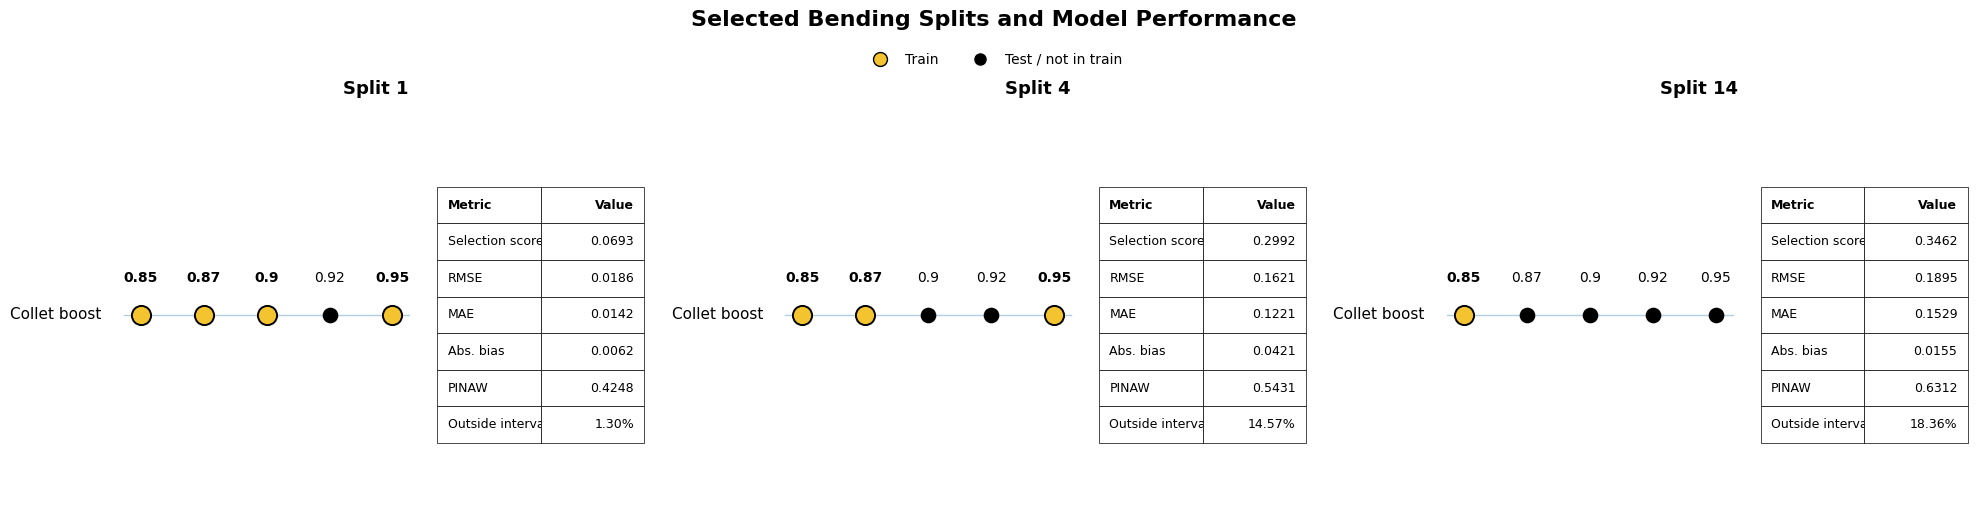

In [87]:
plot_kept_splits(
    splits_df=splits_to_keep_df,
    figsize=(20, 5),
)

# Train With Selected Splitting